# Stage 3: Exploratory Data Analysis

Loads the cleaned dataset from Stage 2 and produces EDA visualizations:
feature distributions, correlation heatmap, state-level SVI (bar chart +
choropleth), and the census-region map.

**Requires:** `processed/county_data_cleaned.csv`
**Produces:** nothing persisted (visual output only)

In [3]:
# IMPORT LIBRARIES
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from google.colab import drive

In [4]:
# MOUNT DRIVE AND LOAD CLEANED DATASET

drive.mount("/content/drive")

FOLDER_NAME = "data"
DATASET_PATH = f"/content/drive/MyDrive/{FOLDER_NAME}"
PROCESSED_DIR = f"{DATASET_PATH}/processed"

df = pd.read_csv(f"{PROCESSED_DIR}/county_data_cleaned.csv", dtype={"FIPS": str})
print(f"✅ SUCCESS: loaded cleaned dataset ({df.shape[0]} rows, {df.shape[1]} cols)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ SUCCESS: loaded cleaned dataset (3144 rows, 31 cols)


In [6]:
# ADD DATA VISUALIZATIONS (EDA) HERE
# Plot ideas: feature distributions, correlation heatmap
#(check for multicollinearity), state-lvl vulnerability for pattern check

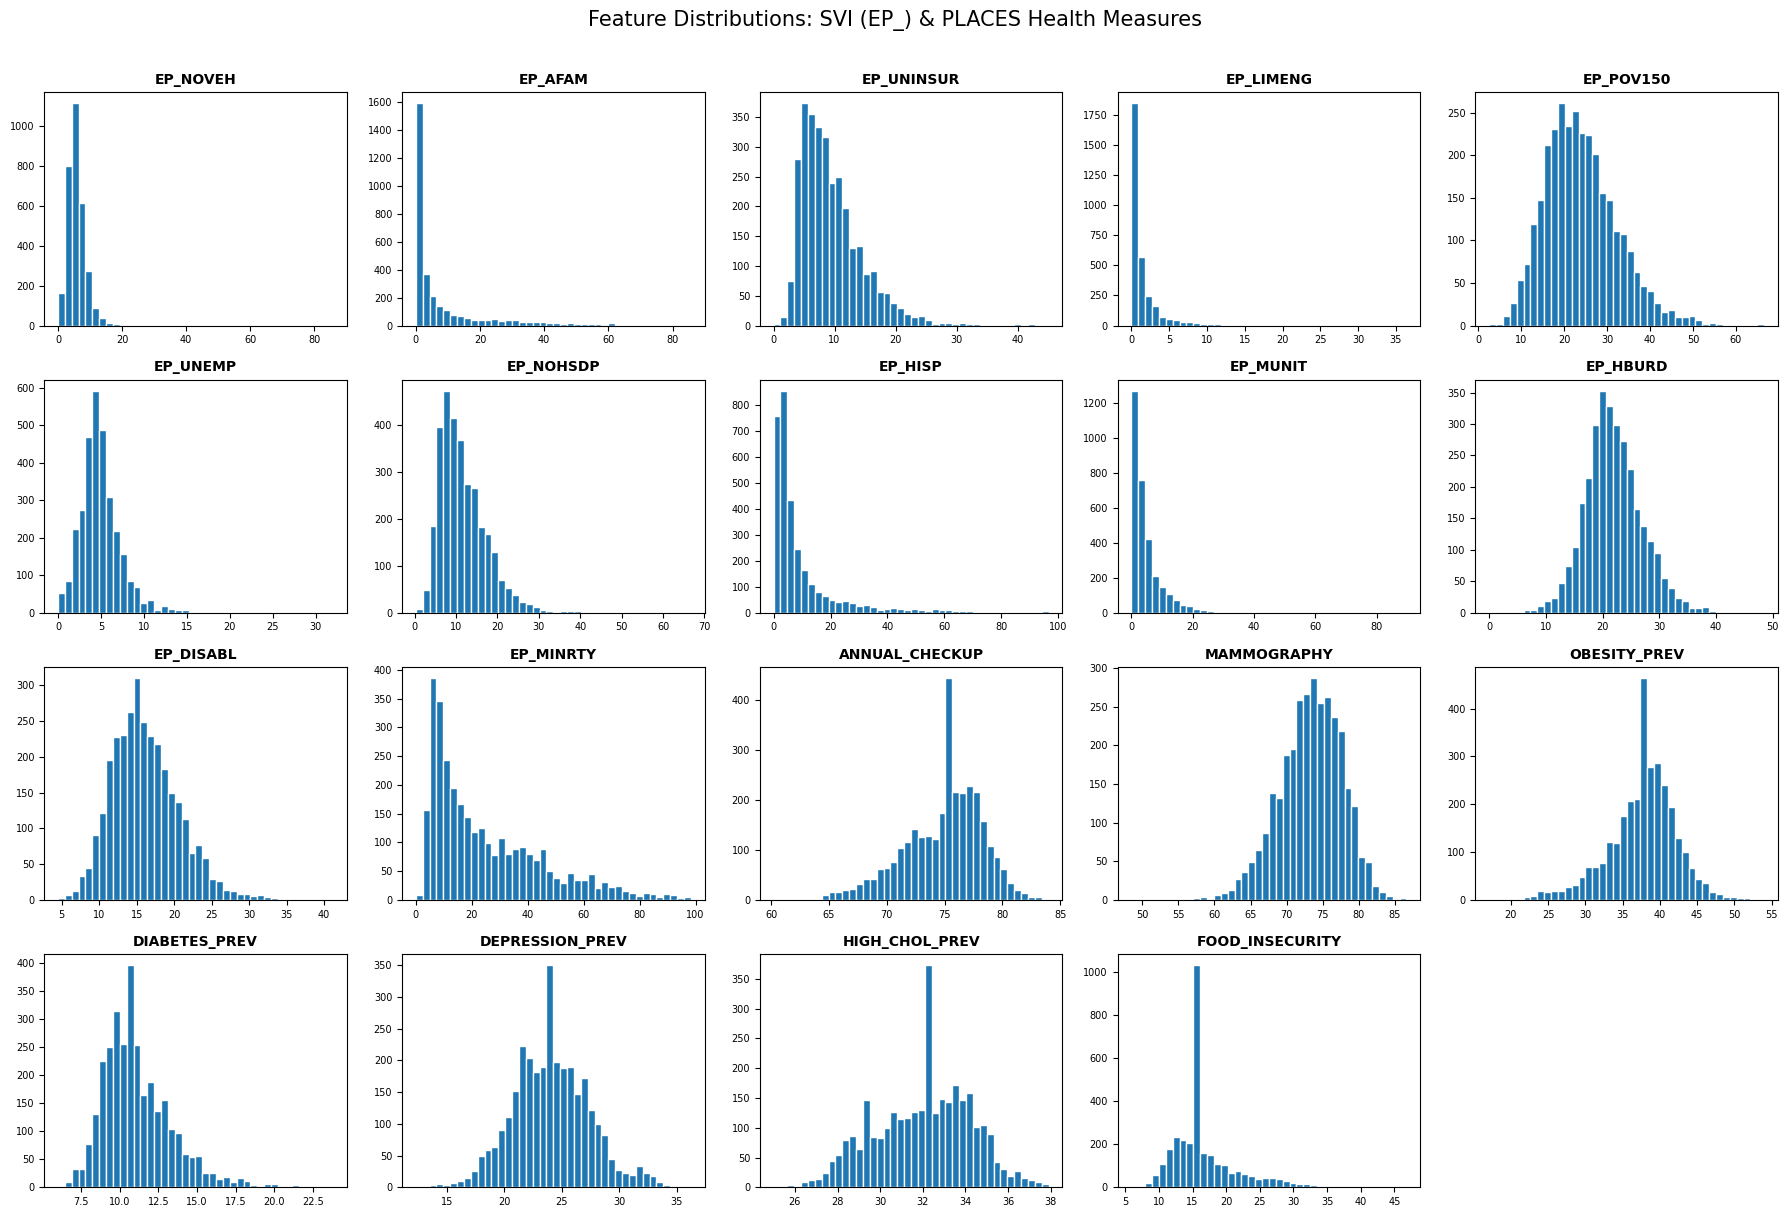

In [5]:
# Visualization 1: Feature Distributions
svi_cols  = [c for c in df.columns if c.startswith("EP_")]

places_cols = ["ANNUAL_CHECKUP", "MAMMOGRAPHY", "OBESITY_PREV",
            "DIABETES_PREV", "DEPRESSION_PREV", "HIGH_CHOL_PREV",
               "FOOD_INSECURITY"]

plot_cols = svi_cols + places_cols   # 19 total

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=40, edgecolor="white")
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].tick_params(labelsize=7)

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions: SVI (EP_) & PLACES Health Measures",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**Key Observations for Visualization 1:**
- Most SVI features like `EP_AFAM`, `EP_LIMENG`, and `EP_MUNIT`are right-skewed. That means the majority of counties have low values with a long tail of high-vulnerability outliers.
- PLACES health measures like `MAMMOGRAPHY`, `ANNUAL_CHECKUP`, and `OBESITY_PREV` are normally distributed, meaning these outcomes vary more evenly across counties
- `MAMMOGRAPHY` is approximately normally distributed. The remaining PLACES health measures (`ANNUAL_CHECKUP`, `OBESITY_PREV`, `DIABETES_PREV`, `DEPRESSION_PREV`, `HIGH_COL_PREV`) show a visible spike at their median value, cuased by median imputation applied to the **188** Kentucky and Pennsylvania counties missing from PLACES 2025.
- `FOOD_INSECURITY` stands out with the sharpest spike near its median due a larger imputation of **844** counties.

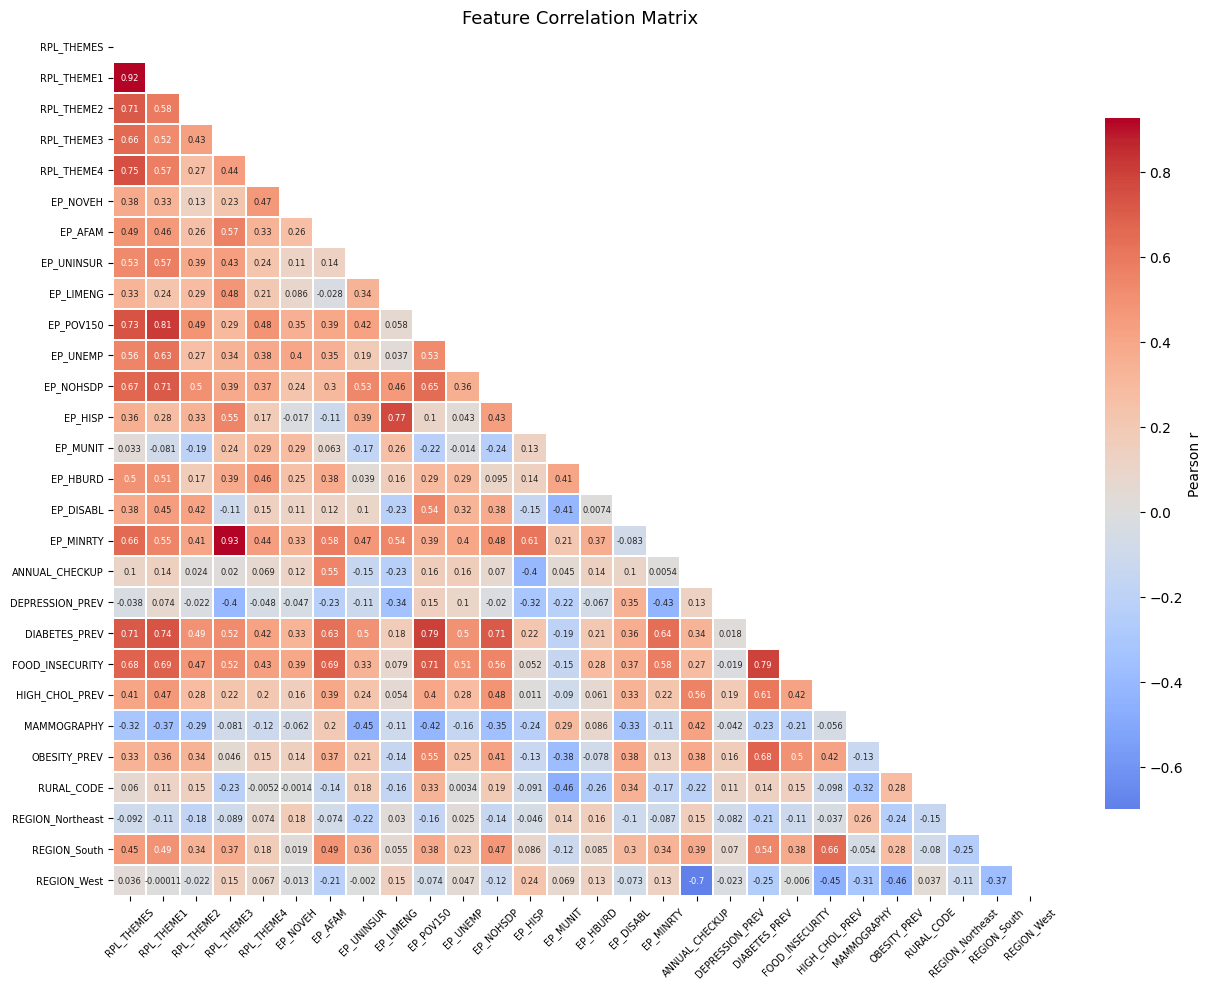

Highly correlated pairs (|r| > 0.75): 6
      Feature_A     Feature_B        r
      EP_MINRTY    RPL_THEME3 0.926847
     RPL_THEME1    RPL_THEMES 0.921377
      EP_POV150    RPL_THEME1 0.808009
  DIABETES_PREV     EP_POV150 0.794573
FOOD_INSECURITY DIABETES_PREV 0.791787
        EP_HISP     EP_LIMENG 0.770456


In [7]:
# Visualization 2: Correlation Heatmap

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr     = df[num_cols].corr() # Pearson correlation coefficient

fig, ax  = plt.subplots(figsize=(13, 10))
mask     = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle

sns.heatmap(
    data=corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    annot_kws={"size": 6},
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)

ax.set_title("Feature Correlation Matrix", fontsize=13)
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()

# Flag pairs with |r| > 0.75 for multicollinearity review
# Why |r| > 0.75? See https://pmc.ncbi.nlm.nih.gov/articles/PMC6107969/
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ["Feature_A", "Feature_B", "r"]
high_corr = corr_pairs[corr_pairs["r"].abs() > 0.75].sort_values("r", ascending=False)
print(f"Highly correlated pairs (|r| > 0.75): {len(high_corr)}")
print(high_corr.to_string(index=False))

**Key Observations for Visualization 2**:
- There are several highly correlated pairs:
  - `EP_MINRTY` and `RPL_THEME3` (r = 0.926847)
  - `RPL_THEME1` and `RPL_THEMES` (r = 0.921377)
  - `EP_POV150` and `RPL_THEME1` (r = 0.808009)
  - `DIABETES_PREV` and `EP_POV150` (r = 0.781408)
  - `EP_HISP` and `EP_LIMENG` (r = 0.770456)
  - `FEED_INSECURITY` and `DIABETES_PREV` (r = 0.769598)

  Some of these make sense. For instance, poverty (`EP_POV1501`) drives both diabetes prevalence (`DIABETES_PREV`) and food insecurity (`FOOD_INSECURITY`)

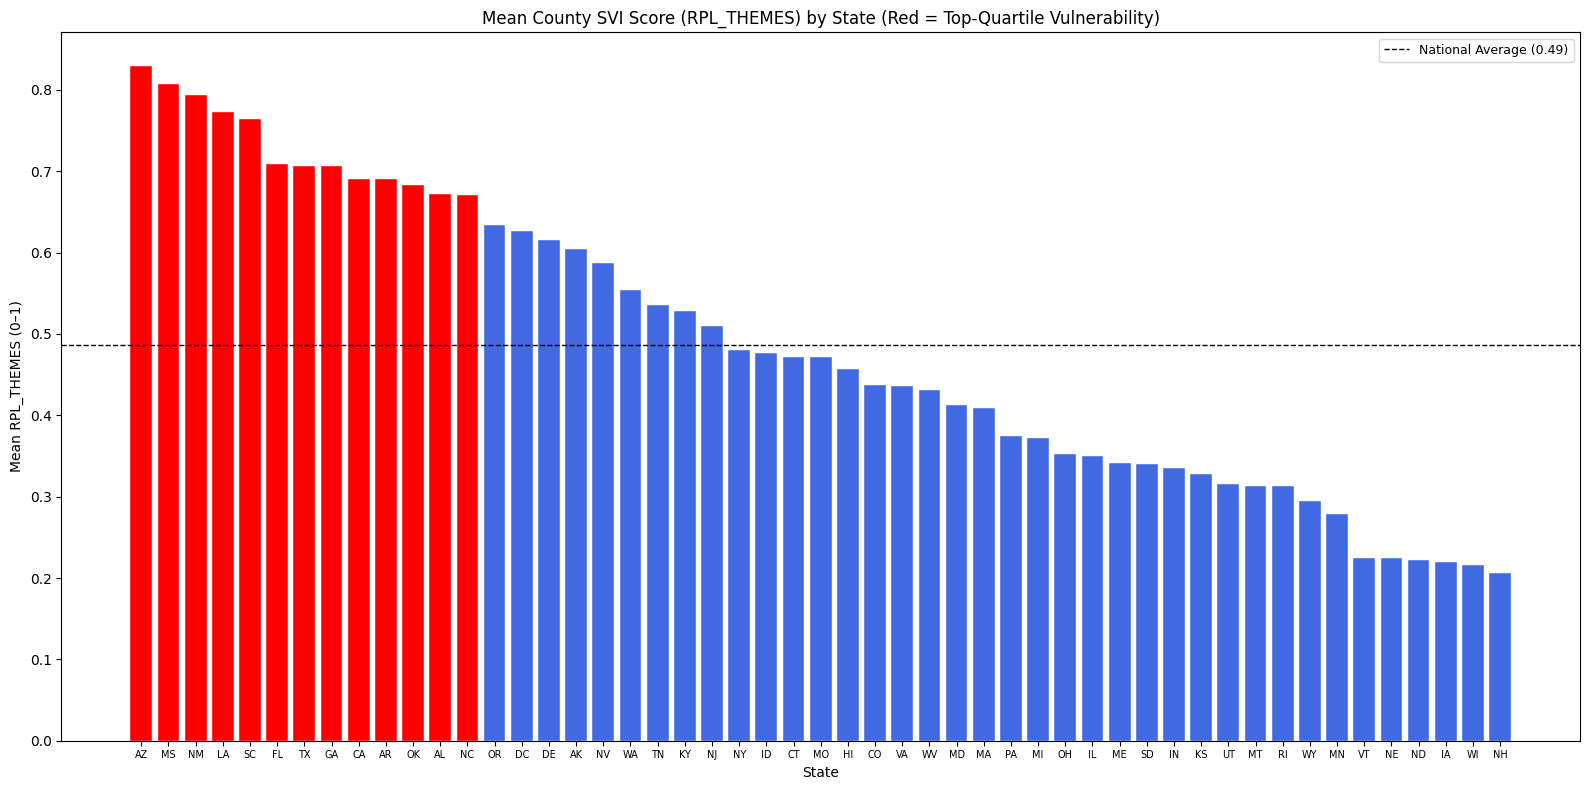

In [8]:
# Visualization 3: State-Level Mean Social Vulnerability

state_svi = (
    df.groupby("ST_ABBR")["RPL_THEMES"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

nat_avg = state_svi["RPL_THEMES"].mean()
q75     = state_svi["RPL_THEMES"].quantile(0.75)

colors = ["red" if v >= q75 else "royalblue" for v in state_svi["RPL_THEMES"]]

fig, ax = plt.subplots(figsize=(16, 8))
ax.bar(state_svi["ST_ABBR"], state_svi["RPL_THEMES"],
       color=colors, edgecolor="white", linewidth=0.3)
ax.axhline(nat_avg, color="black", linestyle="--", linewidth=1,
           label=f"National Average ({nat_avg:.2f})")
ax.set_title("Mean County SVI Score (RPL_THEMES) by State (Red = Top-Quartile Vulnerability)",
             fontsize=12)
ax.set_xlabel("State")
ax.set_ylabel("Mean RPL_THEMES (0–1)")
ax.tick_params(axis="x", labelsize=7)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Key Observations for Visualization 3:**
- Southern and Gulf Coast states (Mississippi, Louisiana, New Mexico, Arkansas, South Carolina) have the highest mean county-level SVI score.
- There's a drop off after North Carolina, after which no state exceeds the national average of 0.49.
- New England and Upper Midwest states (Vermont, New Hampshire, Minnesota, Wisconsin) have the lowest mean county-level SVI score.

In [9]:
# Visualization 3b: State-Level Mean Social Vulnerability (Choropleth)
# Map view of the same state_svi data as Visualization 3's bar chart

fig = px.choropleth(
    state_svi,
    locations='ST_ABBR',
    locationmode='USA-states',
    color='RPL_THEMES',
    scope='usa',
    color_continuous_scale='Viridis_r',
    title='Mean County SVI Score (RPL_THEMES) by State',
    hover_name='ST_ABBR',
    hover_data={'RPL_THEMES': ':.2f'}
)

fig.update_layout(
    geo_scope='usa',
    geo_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)'
)

fig.show()

In [10]:
# Visualization 4: US Census Region Map
# Shows the 4 Census Bureau regions used as geographic feature in the model
# NOTE: mirrors the region_map lookup used in data_cleaning.ipynb to
# engineer the REGION_* dummy columns - duplicated here since it's a
# static lookup table, not data derived from df.

region_map = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast',
    'RI':'Northeast','VT':'Northeast','NJ':'Northeast','NY':'Northeast',
    'PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest',
    'IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest',
    'ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South',
    'SC':'South','VA':'South','DC':'South','WV':'South','AL':'South',
    'KY':'South','MS':'South','TN':'South','AR':'South','LA':'South',
    'OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West',
    'UT':'West','WY':'West','AK':'West','CA':'West','HI':'West','OR':'West',
    'WA':'West'
}

region_df = pd.DataFrame(list(region_map.items()), columns=["ST_ABBR", "REGION"])

fig = px.choropleth(
    region_df,
    locations="ST_ABBR",
    locationmode="USA-states",
    color="REGION",
    scope="usa",
    title="US Census Bureau Regions (Geographic Feature)",
    color_discrete_map={
        "Northeast": "#4e79a7",
        "Midwest":   "#f28e2b",
        "South":     "#e15759",
        "West":      "#76b7b2",
    },
    hover_name="ST_ABBR",
    hover_data={"ST_ABBR": False, "REGION": True}
)
fig.update_layout(
    legend_title_text="Region",
    geo_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)"
)
fig.show()